In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [2]:
df = pd.read_csv("heart.csv")

In [3]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [5]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='RestingBP'>

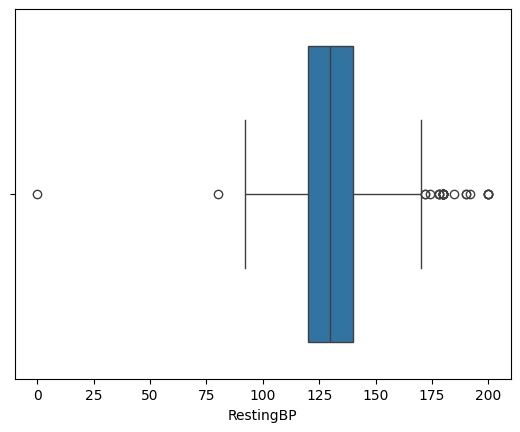

In [7]:
sns.boxplot(x = df["RestingBP"])

<Axes: xlabel='RestingBP', ylabel='Count'>

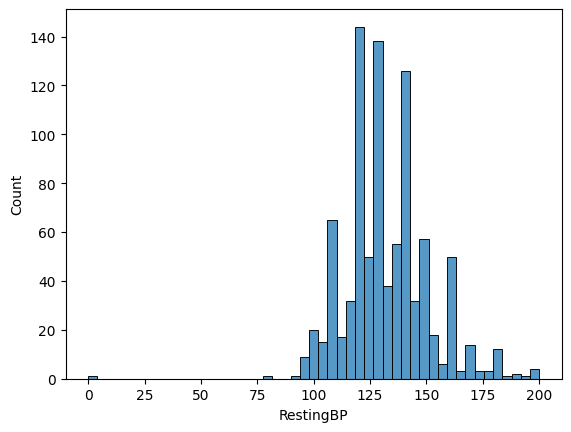

In [8]:
sns.histplot(x = df["RestingBP"])

In [9]:
import pandas as pd

# Calculate Q1, Q3, and IQR
Q1 = df["RestingBP"].quantile(0.25)
Q3 = df["RestingBP"].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Calculate mean of the column
mean_value = df["RestingBP"].mean()

# Replace outliers with mean
df["RestingBP"] = df["RestingBP"].apply(
    lambda x: mean_value if (x < lower_bound or x > upper_bound) else x
)


<Axes: xlabel='RestingBP', ylabel='Count'>

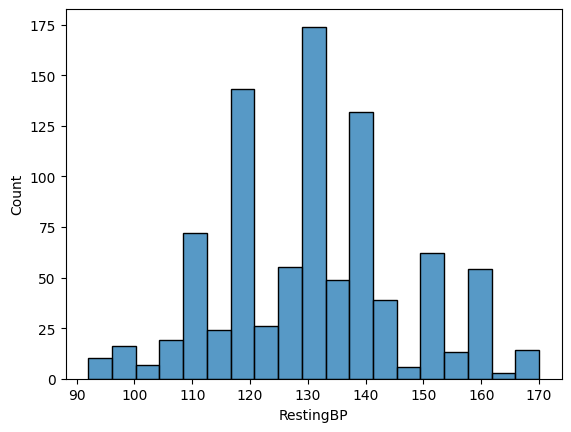

In [10]:
sns.histplot(x = df["RestingBP"])

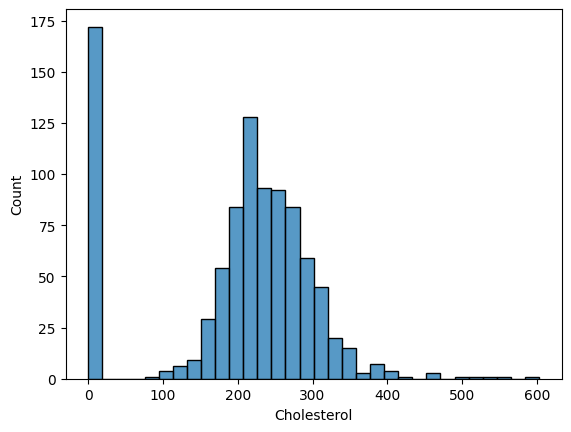

In [11]:
def plot_hist(var):
    sns.histplot(df[var])

plot_hist("Cholesterol")

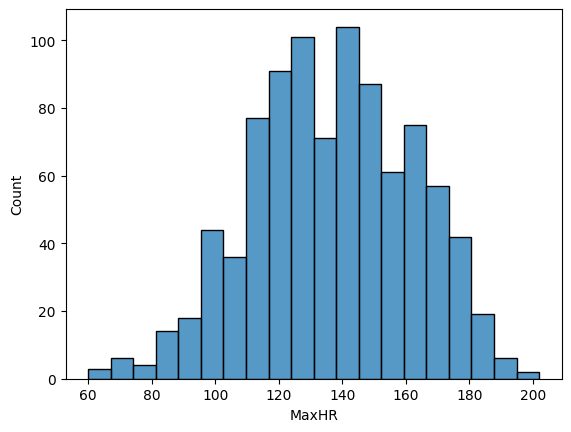

In [12]:
plot_hist("MaxHR")

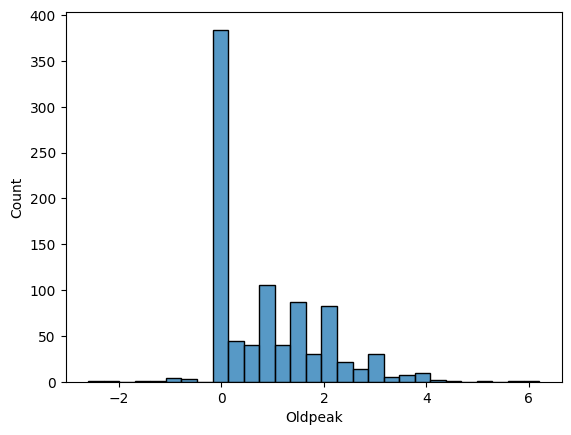

In [13]:
plot_hist("Oldpeak")

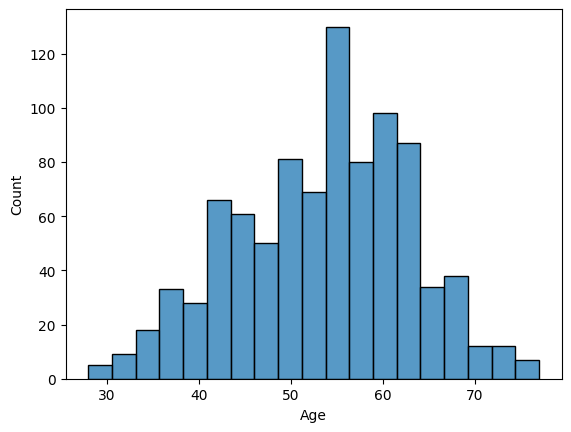

In [14]:
plot_hist("Age")

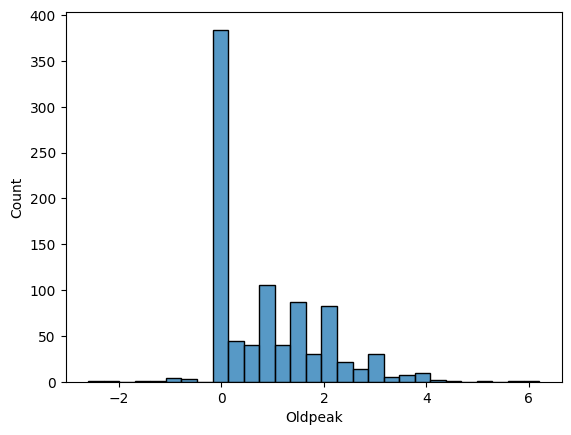

In [15]:
plot_hist("Oldpeak")

In [16]:
corr = df.corr(numeric_only = True)

In [17]:
corr

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.270244,-0.095282,0.198039,-0.382045,0.258612,0.282039
RestingBP,0.270244,1.000000,0.088868,0.050226,-0.107270,0.183563,0.108877
Cholesterol,-0.095282,0.088868,1.000000,-0.260974,0.235792,0.050148,-0.232741
FastingBS,0.198039,0.050226,-0.260974,1.000000,-0.131438,0.052698,0.267291
MaxHR,-0.382045,-0.107270,0.235792,-0.131438,1.000000,-0.160691,-0.400421
Oldpeak,0.258612,0.183563,0.050148,0.052698,-0.160691,1.000000,0.403951
HeartDisease,0.282039,0.108877,-0.232741,0.267291,-0.400421,0.403951,1.000000


<Axes: >

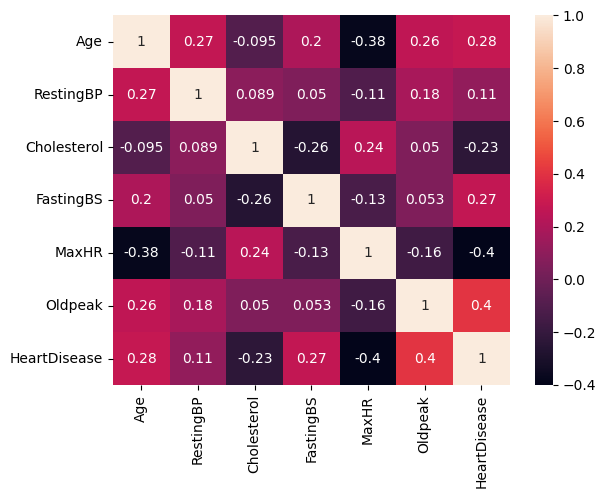

In [18]:
sns.heatmap(data = corr, annot = True)

In [19]:
df_cleaned = pd.get_dummies(df,columns = ["ChestPainType","RestingECG","ST_Slope"])


In [20]:
df_cleaned["Sex"] = df_cleaned["Sex"].replace({"M":1,"F":0})
df_cleaned["ExerciseAngina"] = df_cleaned["ExerciseAngina"].replace({"Y":1,"N":0})

In [21]:
df_cleaned

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140.0,289,0,172,0,0.0,0,False,True,False,False,False,True,False,False,False,True
1,49,0,160.0,180,0,156,0,1.0,1,False,False,True,False,False,True,False,False,True,False
2,37,1,130.0,283,0,98,0,0.0,0,False,True,False,False,False,False,True,False,False,True
3,48,0,138.0,214,0,108,1,1.5,1,True,False,False,False,False,True,False,False,True,False
4,54,1,150.0,195,0,122,0,0.0,0,False,False,True,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,110.0,264,0,132,0,1.2,1,False,False,False,True,False,True,False,False,True,False
914,68,1,144.0,193,1,141,0,3.4,1,True,False,False,False,False,True,False,False,True,False
915,57,1,130.0,131,0,115,1,1.2,1,True,False,False,False,False,True,False,False,True,False
916,57,0,130.0,236,0,174,0,0.0,1,False,True,False,False,True,False,False,False,True,False


In [22]:
df_cleaned = df_cleaned.astype(int)
df_cleaned

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0,0,0,1,0,0,0,1,0,0,0,1
1,49,0,160,180,0,156,0,1,1,0,0,1,0,0,1,0,0,1,0
2,37,1,130,283,0,98,0,0,0,0,1,0,0,0,0,1,0,0,1
3,48,0,138,214,0,108,1,1,1,1,0,0,0,0,1,0,0,1,0
4,54,1,150,195,0,122,0,0,0,0,0,1,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,110,264,0,132,0,1,1,0,0,0,1,0,1,0,0,1,0
914,68,1,144,193,1,141,0,3,1,1,0,0,0,0,1,0,0,1,0
915,57,1,130,131,0,115,1,1,1,1,0,0,0,0,1,0,0,1,0
916,57,0,130,236,0,174,0,0,1,0,1,0,0,1,0,0,0,1,0


In [24]:
from sklearn.preprocessing import StandardScaler
cols = ["Age","RestingBP","Cholesterol","MaxHR","Oldpeak"]
scaler = StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [25]:
df_cleaned.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,1,0.568342,0.825070,0,1.382928,0,-0.727592,0,0,1,0,0,0,1,0,0,0,1
1,-0.478484,0,1.851358,-0.171961,0,0.754157,0,0.282891,1,0,0,1,0,0,1,0,0,1,0
2,-1.751359,1,-0.073165,0.770188,0,-1.525138,0,-0.727592,0,0,1,0,0,0,0,1,0,0,1
3,-0.584556,0,0.440041,0.139040,0,-1.132156,1,0.282891,1,1,0,0,0,0,1,0,0,1,0
4,0.051881,1,1.209850,-0.034755,0,-0.581981,0,-0.727592,0,0,0,1,0,0,1,0,0,0,1


In [27]:
df_cleaned.describe()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
count,9.180000e+02,918.000000,9.180000e+02,918.000000,918.000000,9.180000e+02,918.000000,9.180000e+02,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,-1.083616e-16,0.789760,-3.212149e-16,0.000000,0.233115,4.953675e-16,0.404139,8.514129e-17,0.553377,0.540305,0.188453,0.221133,0.050109,0.204793,0.601307,0.193900,0.068627,0.501089,0.430283
std,1.000545e+00,0.407701,1.000545e+00,1.000545,0.423046,1.000545e+00,0.490992,1.000545e+00,0.497414,0.498645,0.391287,0.415236,0.218289,0.403770,0.489896,0.395567,0.252957,0.500271,0.495386
min,-2.706015e+00,0.000000,-2.510895e+00,-1.818435,0.000000,-3.018469e+00,0.000000,-2.748559e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-6.906294e-01,1.000000,-7.146731e-01,-0.233704,0.000000,-6.605778e-01,0.000000,-7.275920e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.188098e-02,1.000000,-7.316542e-02,0.221363,0.000000,4.678968e-02,0.000000,-7.275920e-01,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,6.883185e-01,1.000000,5.683423e-01,0.623835,0.000000,7.541571e-01,1.000000,2.828913e-01,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,2.491558e+00,1.000000,2.492865e+00,3.697252,1.000000,2.561874e+00,1.000000,5.335308e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [28]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    float64
 1   Sex                918 non-null    int64  
 2   RestingBP          918 non-null    float64
 3   Cholesterol        918 non-null    float64
 4   FastingBS          918 non-null    int64  
 5   MaxHR              918 non-null    float64
 6   ExerciseAngina     918 non-null    int64  
 7   Oldpeak            918 non-null    float64
 8   HeartDisease       918 non-null    int64  
 9   ChestPainType_ASY  918 non-null    int64  
 10  ChestPainType_ATA  918 non-null    int64  
 11  ChestPainType_NAP  918 non-null    int64  
 12  ChestPainType_TA   918 non-null    int64  
 13  RestingECG_LVH     918 non-null    int64  
 14  RestingECG_Normal  918 non-null    int64  
 15  RestingECG_ST      918 non-null    int64  
 16  ST_Slope_Down      918 non-null    in

In [29]:
df_cleaned.duplicated().sum()

np.int64(0)

In [30]:
from scipy.stats import pearsonr

selected_features = ["Age","Sex","RestingBP","Cholesterol",	"FastingBS","MaxHR","ExerciseAngina",
                    "Oldpeak","ChestPainType_ASY","ChestPainType_ATA","ChestPainType_NAP","ChestPainType_TA","RestingECG_LVH",
                     "RestingECG_Normal","RestingECG_ST","ST_Slope_Down","ST_Slope_Flat","ST_Slope_Up"]
correlations = {
feature: pearsonr(df_cleaned[feature], df_cleaned['HeartDisease']) [0]
for feature in selected_features
} 

correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation' ] )
correlation_df.sort_values(by='Pearson Correlation', ascending = False)

,Feature,Pearson Correlation
16,ST_Slope_Flat,0.554134
8,ChestPainType_ASY,0.516716
6,ExerciseAngina,0.494282
7,Oldpeak,0.392385
1,Sex,0.305445
0,Age,0.282039
4,FastingBS,0.267291
15,ST_Slope_Down,0.122527
2,RestingBP,0.108743
14,RestingECG_ST,0.102527


In [40]:
cat_var = ["ChestPainType_ASY","ST_Slope_Flat","ST_Slope_Up","ChestPainType_ATA","ExerciseAngina",
           "Oldpeak","Sex","MaxHR","Age"]

In [41]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['HeartDisease_bin'] = pd.qcut(df_cleaned['HeartDisease'], q=4, labels=False,duplicates='drop')
chi2_results = {}

for col in cat_var:
    contingency = pd. crosstab(df_cleaned[col], df_cleaned['HeartDisease_bin'])
    chi2_stat, p_val, _, _= chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
    'chi2_statistic': chi2_stat,
    'p_value': p_val,
    'Decision': decision
    }
chi2_df = pd.DataFrame(chi2_results).T
chi2_df= chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
ChestPainType_ASY,0.0,1.0,Accept Null (Drop Feature)
ST_Slope_Flat,0.0,1.0,Accept Null (Drop Feature)
ST_Slope_Up,0.0,1.0,Accept Null (Drop Feature)
ChestPainType_ATA,0.0,1.0,Accept Null (Drop Feature)
ExerciseAngina,0.0,1.0,Accept Null (Drop Feature)
Oldpeak,0.0,1.0,Accept Null (Drop Feature)
Sex,0.0,1.0,Accept Null (Drop Feature)
MaxHR,0.0,1.0,Accept Null (Drop Feature)
Age,0.0,1.0,Accept Null (Drop Feature)


In [37]:
import pandas as pd
from scipy.stats import chi2_contingency

# Define your categorical variables
cat_var = [
    "ChestPainType_ASY", "ST_Slope_Flat", "ST_Slope_Up", 
    "ChestPainType_ATA", "ExerciseAngina", "Sex"
]

# If you want to treat continuous variables like Age, MaxHR, Oldpeak as categorical,
# you should bin them first. Example:
df_cleaned['Age_bin'] = pd.qcut(df_cleaned['Age'], q=4, labels=False)
df_cleaned['MaxHR_bin'] = pd.qcut(df_cleaned['MaxHR'], q=4, labels=False)
df_cleaned['Oldpeak_bin'] = pd.qcut(df_cleaned['Oldpeak'], q=4, labels=False, duplicates='drop')

# Update categorical list to include binned versions
cat_var.extend(["Age_bin", "MaxHR_bin", "Oldpeak_bin"])

alpha = 0.05
chi2_results = {}

# Apply Chi-square test for each categorical variable against HeartDisease
for col in cat_var:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['HeartDisease'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

# Convert results to DataFrame and sort by p-value
chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')

print(chi2_df)


                  chi2_statistic p_value                    Decision
ST_Slope_Up           352.823905     0.0  Reject Null (Keep Feature)
ST_Slope_Flat         279.659914     0.0  Reject Null (Keep Feature)
ChestPainType_ASY     243.021138     0.0  Reject Null (Keep Feature)
ExerciseAngina        222.259383     0.0  Reject Null (Keep Feature)
Oldpeak_bin           176.304777     0.0  Reject Null (Keep Feature)
ChestPainType_ATA     146.236323     0.0  Reject Null (Keep Feature)
MaxHR_bin             136.981818     0.0  Reject Null (Keep Feature)
Sex                    84.145101     0.0  Reject Null (Keep Feature)
Age_bin                81.046587     0.0  Reject Null (Keep Feature)


In [46]:
final_df = df_cleaned[["ST_Slope_Up","ST_Slope_Flat","ExerciseAngina","ChestPainType_ASY","Oldpeak","ChestPainType_ATA"
                       ,"MaxHR","Sex","Age"]]

In [47]:
final_df

,ST_Slope_Up,ST_Slope_Flat,ExerciseAngina,ChestPainType_ASY,Oldpeak,ChestPainType_ATA,MaxHR,Sex,Age
0,1,0,0,0,-0.727592,1,1.382928,1,-1.433140
1,0,1,0,0,0.282891,0,0.754157,0,-0.478484
2,1,0,0,0,-0.727592,1,-1.525138,1,-1.751359
3,0,1,1,1,0.282891,0,-1.132156,0,-0.584556
4,1,0,0,0,-0.727592,0,-0.581981,1,0.051881
...,...,...,...,...,...,...,...,...,...
913,0,1,0,0,0.282891,0,-0.188999,1,-0.902775
914,0,1,0,1,2.303858,0,0.164684,1,1.536902
915,0,1,1,1,0.282891,0,-0.857069,1,0.370100
916,0,1,0,0,-0.727592,1,1.461525,0,0.370100
